In [3]:
!pip install torch
!pip install numpy
!pip install matplotlib

Looking in indexes: https://artifactory.ep.chehejia.com/artifactory/api/pypi/pypi-remote/simple, https://artifactory.ep.chehejia.com/artifactory/api/pypi/pytorch-remote/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 GB 2.1 MB/s eta 0:00:000:00:010:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 70.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.4/348.4 MB 10.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 58.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 MB 33.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 651.8/651.8 kB 41.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 66.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def apply_rope(x, seq_len):
    """Applies RoPE to a [seq_len, dim] tensor."""
    dim = x.shape[-1]
    half_dim = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(0, half_dim) / half_dim).to(x.device)
    positions = torch.arange(seq_len, device=x.device).unsqueeze(1)  # [seq_len, 1]
    angles = positions * freqs.unsqueeze(0)  # [seq_len, half_dim]

    # RoPE rotation: split and apply sin/cos
    cos = torch.cos(angles)
    sin = torch.sin(angles)
    x1, x2 = x[..., :half_dim], x[..., half_dim:]
    x_rotated = torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)
    return x_rotated


In [6]:
# Parameters
seq_len = 2048
dim = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Random (or unit) base query/key vector, shared across positions
base_q = torch.ones(dim, device=device)
base_k = torch.ones(dim, device=device)

# Apply RoPE position embeddings
Q = apply_rope(base_q.unsqueeze(0).repeat(seq_len, 1), seq_len)  # [seq_len, dim]
K0 = apply_rope(base_k.unsqueeze(0), 1)  # [1, dim] — position 0 key

# Compute attention scores between all Q[i] and K[0]
scores = (Q * K0).sum(dim=-1).cpu().numpy()  # shape: [seq_len]


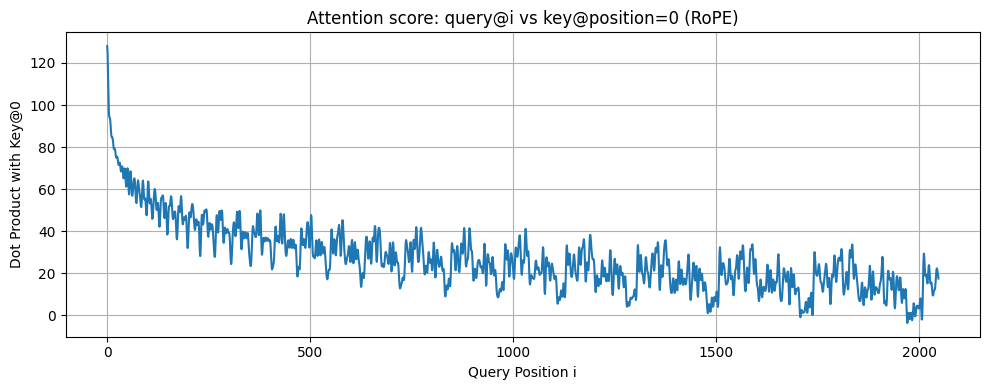

In [7]:
# Plot the score
plt.figure(figsize=(10, 4))
plt.plot(scores)
plt.title("Attention score: query@i vs key@position=0 (RoPE)")
plt.xlabel("Query Position i")
plt.ylabel("Dot Product with Key@0")
plt.grid(True)
plt.tight_layout()
plt.show()